4. Using this housing price prediction dataset, fit a regression model using sklearn. Apply all the preprocessing and EDA before fitting to the model. Evaluate the model and interpret the conclusion like which feature plays a significant role for high prices. Also show all possible conclusions and studies visually.

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [18]:
df=pd.read_csv('housing_price_dataset.csv')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [20]:
df.head(5)

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


In [21]:
df['Neighborhood'].value_counts()

Neighborhood
Suburb    16721
Rural     16676
Urban     16603
Name: count, dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  object 
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.3+ MB


In [23]:
df.isnull().sum()

SquareFeet      0
Bedrooms        0
Bathrooms       0
Neighborhood    0
YearBuilt       0
Price           0
dtype: int64

In [24]:
df.duplicated().sum()

0

In [25]:
df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,2006.374680,3.498700,1.995420,1985.404420,224827.325151
std,575.513241,1.116326,0.815851,20.719377,76141.842966
min,1000.000000,2.000000,1.000000,1950.000000,-36588.165397
25%,1513.000000,3.000000,1.000000,1967.000000,169955.860225
50%,2007.000000,3.000000,2.000000,1985.000000,225052.141166
75%,2506.000000,4.000000,3.000000,2003.000000,279373.630052
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [26]:
df['Price'].min()

-36588.16539749279

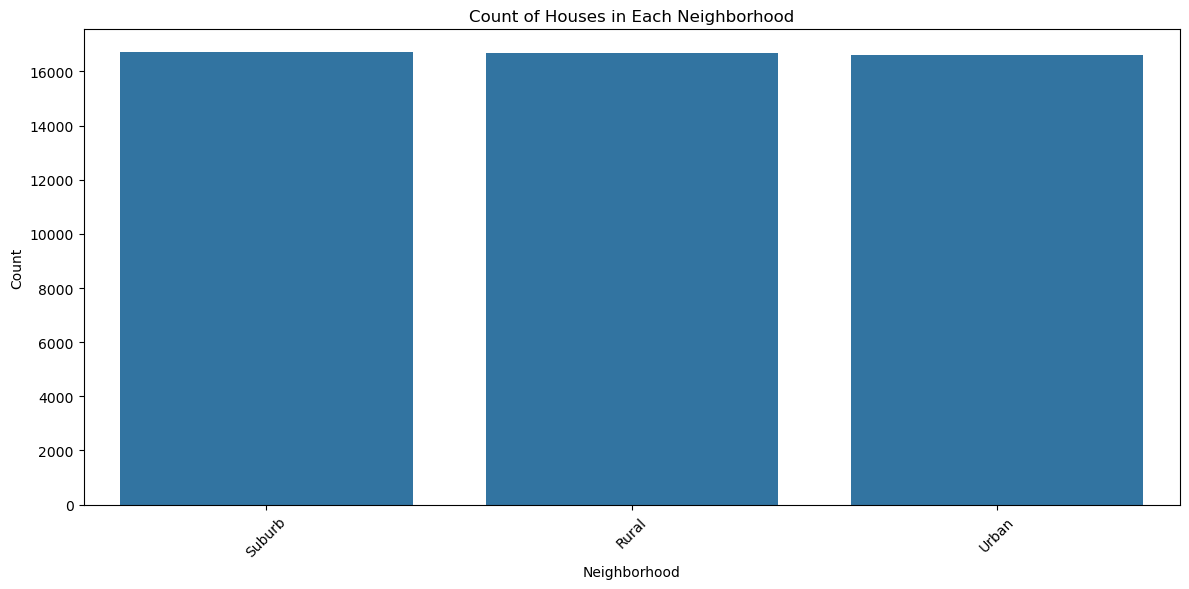

In [27]:
# code to plot the countplot of neighborhoods
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Neighborhood', order=df['Neighborhood'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Count of Houses in Each Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


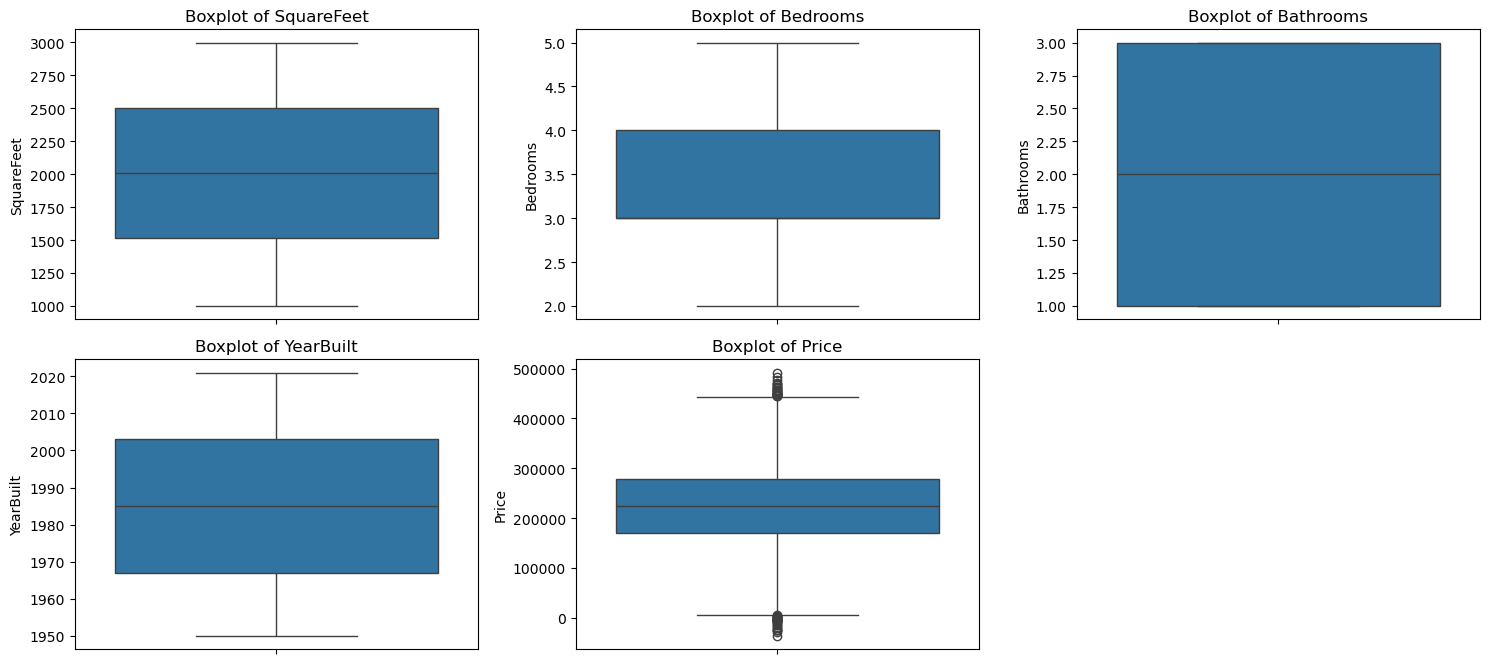

In [28]:
# code to display the boxplot of each numerical feature
plt.figure(figsize=(15, 10))
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=df, y=feature)
    plt.title(f'Boxplot of {feature}')
    plt.tight_layout()
plt.show()


In [29]:
df.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153
4,2130,5,2,Suburb,2001,272436.239065


In [31]:
# remove all the rows with negative prices
df = df[df['Price'] >= 0]
# remove all the rows with negative square footage

In [32]:
df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,49978.000000,49978.000000,49978.000000,49978.000000,49978.000000
mean,2006.752551,3.498659,1.995458,1985.404338,224931.667960
std,575.350298,1.116325,0.815859,20.718407,75995.682992
min,1000.000000,2.000000,1.000000,1950.000000,154.779120
25%,1514.000000,3.000000,1.000000,1967.000000,170007.487130
50%,2008.000000,3.000000,2.000000,1985.000000,225100.123857
75%,2506.000000,4.000000,3.000000,2003.000000,279395.826288
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [34]:
df['Bedrooms'].value_counts()

Bedrooms
3    12656
5    12462
2    12431
4    12429
Name: count, dtype: int64

In [36]:
df['Bathrooms'].value_counts()

Bathrooms
1    16747
2    16711
3    16520
Name: count, dtype: int64

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49978 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    49978 non-null  int64  
 1   Bedrooms      49978 non-null  int64  
 2   Bathrooms     49978 non-null  int64  
 3   Neighborhood  49978 non-null  object 
 4   YearBuilt     49978 non-null  int64  
 5   Price         49978 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 2.7+ MB


In [38]:
df.describe()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price
count,49978.000000,49978.000000,49978.000000,49978.000000,49978.000000
mean,2006.752551,3.498659,1.995458,1985.404338,224931.667960
std,575.350298,1.116325,0.815859,20.718407,75995.682992
min,1000.000000,2.000000,1.000000,1950.000000,154.779120
25%,1514.000000,3.000000,1.000000,1967.000000,170007.487130
50%,2008.000000,3.000000,2.000000,1985.000000,225100.123857
75%,2506.000000,4.000000,3.000000,2003.000000,279395.826288
max,2999.000000,5.000000,3.000000,2021.000000,492195.259972


In [39]:
df = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True)


In [40]:
df.head()

,SquareFeet,Bedrooms,Bathrooms,YearBuilt,Price,Neighborhood_Suburb,Neighborhood_Urban
0,2126,4,1,1969,215355.283618,False,False
1,2459,3,2,1980,195014.221626,False,False
2,1860,2,1,1970,306891.012076,True,False
3,2294,2,1,1996,206786.787153,False,True
4,2130,5,2,2001,272436.239065,True,False


In [41]:
df['HouseAge'] = 2025 - df['YearBuilt']
df.drop('YearBuilt', axis=1, inplace=True)
df.head()

,SquareFeet,Bedrooms,Bathrooms,Price,Neighborhood_Suburb,Neighborhood_Urban,HouseAge
0,2126,4,1,215355.283618,False,False,56
1,2459,3,2,195014.221626,False,False,45
2,1860,2,1,306891.012076,True,False,55
3,2294,2,1,206786.787153,False,True,29
4,2130,5,2,272436.239065,True,False,24


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
num_cols = ['SquareFeet', 'HouseAge']  # or use 'YearBuilt' if not using HouseAge

df[num_cols] = scaler.fit_transform(df[num_cols])
df.head()

,SquareFeet,Bedrooms,Bathrooms,Price,Neighborhood_Suburb,Neighborhood_Urban,HouseAge
0,0.207263,0.449104,-1.220147,215355.283618,False,False,0.791784
1,0.786046,-0.446702,0.005567,195014.221626,False,False,0.260850
2,-0.255069,-1.342507,-1.220147,306891.012076,True,False,0.743517
3,0.499262,-1.342507,-1.220147,206786.787153,False,True,-0.511418
4,0.214215,1.344909,0.005567,272436.239065,True,False,-0.752752


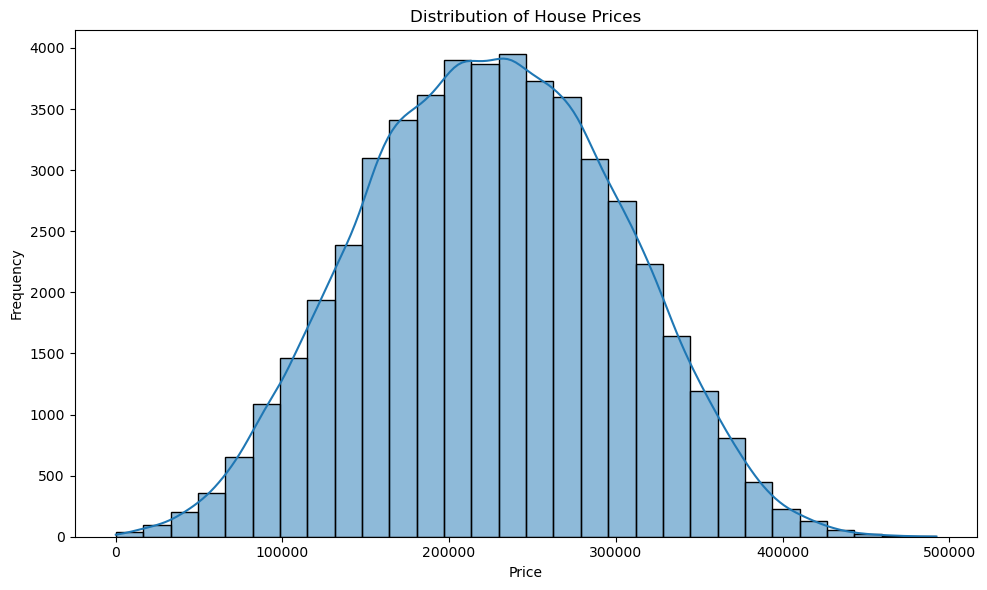

In [43]:
#plot to see distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [44]:
df.head()

,SquareFeet,Bedrooms,Bathrooms,Price,Neighborhood_Suburb,Neighborhood_Urban,HouseAge
0,0.207263,0.449104,-1.220147,215355.283618,False,False,0.791784
1,0.786046,-0.446702,0.005567,195014.221626,False,False,0.260850
2,-0.255069,-1.342507,-1.220147,306891.012076,True,False,0.743517
3,0.499262,-1.342507,-1.220147,206786.787153,False,True,-0.511418
4,0.214215,1.344909,0.005567,272436.239065,True,False,-0.752752


In [45]:
df.to_csv('cleaned_housing_price_dataset.csv', index=False)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49978 entries, 0 to 49999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SquareFeet           49978 non-null  float64
 1   Bedrooms             49978 non-null  float64
 2   Bathrooms            49978 non-null  float64
 3   Price                49978 non-null  float64
 4   Neighborhood_Suburb  49978 non-null  bool   
 5   Neighborhood_Urban   49978 non-null  bool   
 6   HouseAge             49978 non-null  float64
dtypes: bool(2), float64(5)
memory usage: 2.4 MB


In [47]:
df.describe()

,SquareFeet,Bedrooms,Bathrooms,Price,HouseAge
count,4.997800e+04,4.997800e+04,4.997800e+04,49978.000000,4.997800e+04
mean,-1.265323e-16,-1.536159e-16,-3.056679e-17,224931.667960,1.000174e-16
std,1.000010e+00,1.000010e+00,1.000010e+00,75995.682992,1.000010e+00
min,-1.749826e+00,-1.342507e+00,-1.220147e+00,154.779120,-1.718087e+00
25%,-8.564478e-01,-4.467018e-01,-1.220147e+00,170007.487130,-8.492853e-01
50%,2.168177e-03,-4.467018e-01,5.567194e-03,225100.123857,1.951607e-02
75%,8.677365e-01,4.491036e-01,1.231282e+00,279395.826288,8.883174e-01
max,1.724614e+00,1.344909e+00,1.231282e+00,492195.259972,1.708852e+00


In [48]:
X = df.drop('Price', axis=1)
y = df['Price']


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [50]:
y_pred = model.predict(X_test)


In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R^2  : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")


MAE  : 39490.69
MSE  : 2444275694.75
RMSE : 49439.62
R^2  : 0.5780
MAPE : 24.99%


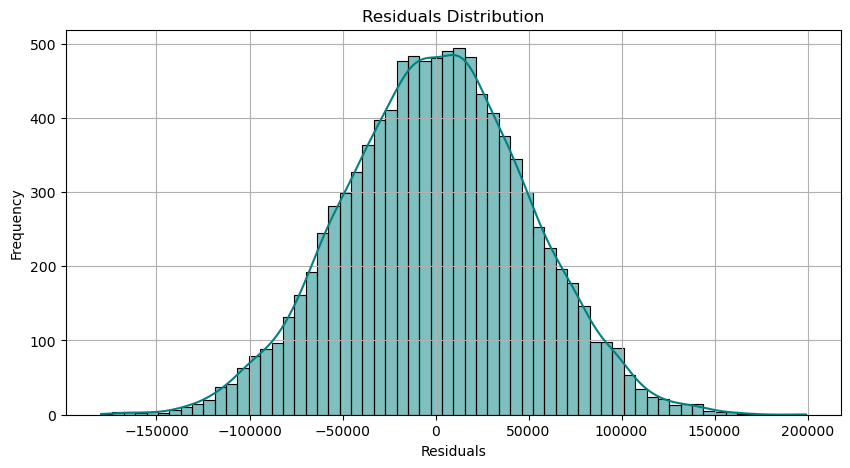

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

residuals = y_test - y_pred

plt.figure(figsize=(10, 5))
sns.histplot(residuals, kde=True, color='teal')
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


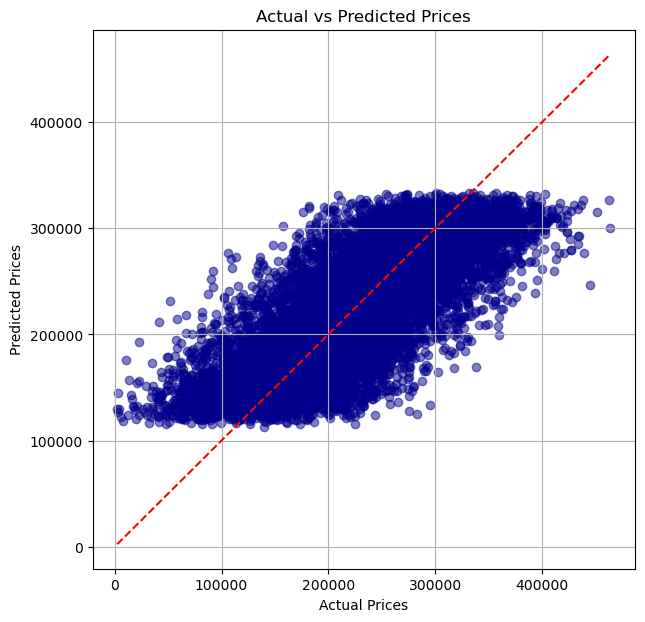

In [53]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.5, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # ideal line
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.grid(True)
plt.show()


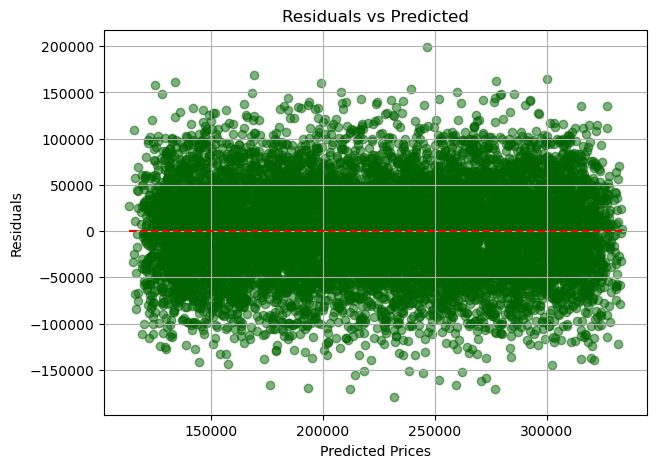

In [54]:
plt.figure(figsize=(7, 5))
plt.scatter(y_pred, residuals, alpha=0.5, color='darkgreen')
plt.hlines(0, xmin=y_pred.min(), xmax=y_pred.max(), colors='red', linestyles='--')
plt.xlabel("Predicted Prices")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.grid(True)
plt.show()


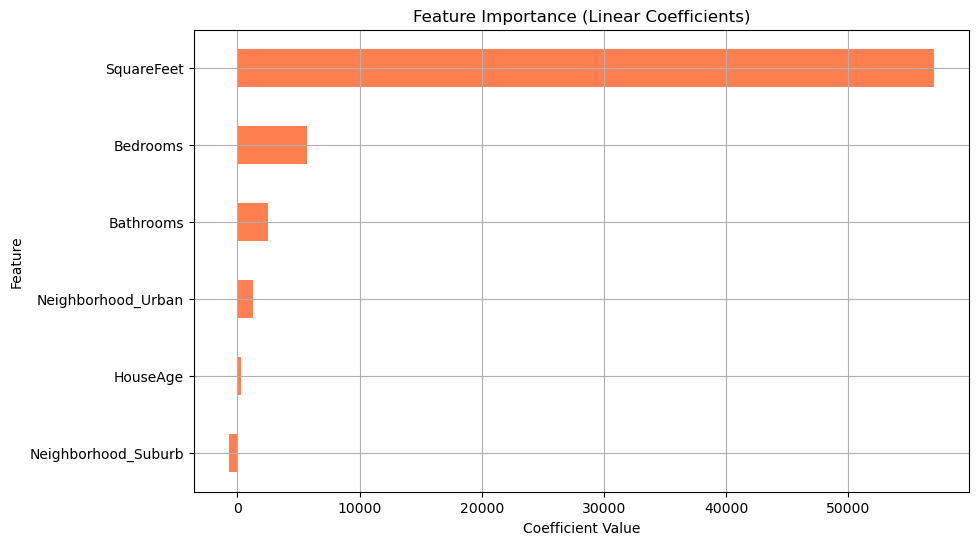

In [55]:
coefficients = pd.Series(model.coef_, index=X.columns)
coefficients = coefficients.sort_values()

plt.figure(figsize=(10, 6))
coefficients.plot(kind='barh', color='coral')
plt.title("Feature Importance (Linear Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.grid(True)
plt.show()
